In [1]:
from rosecdl.rosecdl import RoseCDL
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wfdb
from alphacsc.learn_d_z import compute_X_and_objective, learn_d_z
from alphacsc.learn_d_z_multi import learn_d_z_multi
from alphacsc.update_z import update_z
from scipy.signal.windows import tukey
from wfdb.io.annotation import rdann
from wfdb.io.record import rdrecord


def load_ecg(
    subject_id="a01",
    T=60,
    data_path=Path("apnea-ecg"),
    apply_window=True,
    verbose=True,
):
    """Parameters
    ----------
    subject_id : str
    T : float
        duration, in seconds, of data splits
        default is 60 as the data have been annoted by the minute
    data_path : pathlib.Path
        path to data folder
    apply_window : bool (default: True)
        If set to True (default), a tukey window is applied to each split to
        reduce the border artifacts by reducing the weights of the chunk
        borders.
    verbose : bool
        if True, will print some information

    Returns
    -------
    X : ndarray, shape (n_splits, n_channels, int(T * fs))
        The signal splitted in ``n_splits``,
        whith ``n_splits = sig_len // int(T * fs)``,
        fs being the sampling frequency of the record
    labels : 1d array
        labels corresponding to one minute segments
        i.e., if T = 60, labels have the same length as data and each label
        corresponds to each datta split.
    """  # noqa: D205
    # ECG record
    record_name = str(data_path / subject_id)
    ecg_record = rdrecord(record_name=record_name)

    # split signal
    fs = ecg_record.fs  # sampling frequency of the record
    if verbose:
        print(f"Sampling frequency of the record: {fs} Hz")
    n_times = int(T * fs)
    n_splits = ecg_record.sig_len // n_times
    X = ecg_record.p_signal[: n_splits * n_times, :].T
    X = X.reshape(ecg_record.n_sig, n_splits, n_times).swapaxes(0, 1)

    # Apply a window to the signal to reduce the border artifacts
    if apply_window:
        X *= tukey(n_times, alpha=0.1)[None, None, :]

    # Add labels
    ann = rdann(
        record_name=record_name,
        extension="apn",
        return_label_elements=["symbol"],
        summarize_labels=False,
    )
    labels = np.array(ann.symbol)
    if T == 60:
        # ensure that labels and data have the same number of trials
        n_trials = min(len(ann.symbol), n_splits)
        return X[:n_trials], labels[:n_trials]
    import warnings

    warnings.warn(
        f"The returned labels do not match the data as T != 60 (got T = {T}).",
    )
    return X, labels


In [3]:
X, labels = load_ecg(subject_id="a10")

Sampling frequency of the record: 100 Hz


In [4]:
X.shape, labels.shape, np.unique(labels, return_counts=True)

((516, 1, 6000), (516,), (array(['A', 'N'], dtype='<U1'), array([ 99, 417])))

Text(0.5, 1.0, 'Label: N')

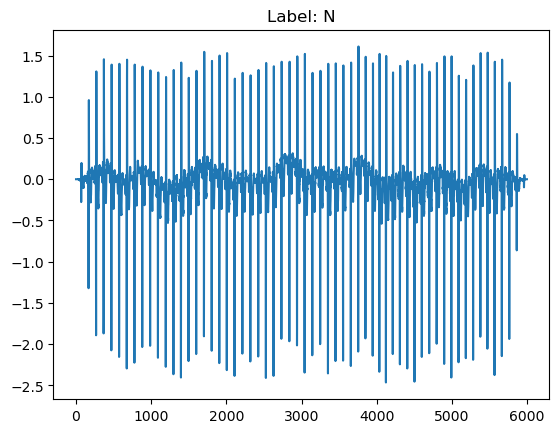

In [5]:
plt.plot(X[22].T)
plt.title(f"Label: {labels[22]}")

In [6]:
losses = {"A" : [], "N": []}
def callback_fn_A(model, epoch, loss):
    losses["A"].append(loss)

def callback_fn_N(model, epoch, loss):
    losses["N"].append(loss)

In [7]:
rose = RoseCDL(
    n_components=3,
    kernel_size=96,
    n_channels=1,
    lmbd=0.1,
    scale_lmbd=True,
    epochs=50,
    max_batch=20,
    mini_batch_size=20,
    sample_window=960,
    window=True,
    device="cuda",
    callbacks=[callback_fn_A],
)

rose_clean = RoseCDL(
    n_components=3,
    kernel_size=96,
    n_channels=1,
    lmbd=0.1,
    scale_lmbd=True,
    epochs=50,
    max_batch=20,
    mini_batch_size=20,
    sample_window=960,
    window=True,
    device="cuda",
    callbacks=[callback_fn_N],
)

In [8]:
X_a = X[labels == "A"]

rose.fit(X_a)

Scaling lambda to 0.5673955678939819
Set up optimizer and scheduler... Done.
TRAINING STARTED


Epoch 4 - Average train loss: 831.093578520275287 - Step size: 5.326926111592911e-05:   8%|▊         | 4/50 [00:03<00:36,  1.26it/s]  

Resampled atom 1


Epoch 50 - Average train loss: 607.123828706287213 - Step size: 0.0006155828014016151: 100%|██████████| 50/50 [00:37<00:00,  1.32it/s] 


RoseCDL(
  (loss_fn): LassoLoss(
    (data_fit): MSELoss()
  )
  (csc): CSC1d()
)

In [9]:
X_clean = X[labels == "N"]

rose_clean.fit(X_clean)

Scaling lambda to 0.7707222104072571
Set up optimizer and scheduler... Done.
TRAINING STARTED


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1 - Average train loss: 1943.509716215587787 - Step size: 0.0016022361814975739:   2%|▏         | 1/50 [00:00<00:29,  1.65it/s]

Resampled atom 2


Epoch 50 - Average train loss: 704.941612606956824 - Step size: 0.0006155828014016151: 100%|██████████| 50/50 [00:32<00:00,  1.56it/s] 


RoseCDL(
  (loss_fn): LassoLoss(
    (data_fit): MSELoss()
  )
  (csc): CSC1d()
)

In [10]:
rose.D_hat_.shape, rose_clean.D_hat_.shape

((3, 1, 96), (3, 1, 96))

Text(0.5, 0.98, 'RoseCDL on apnea data')

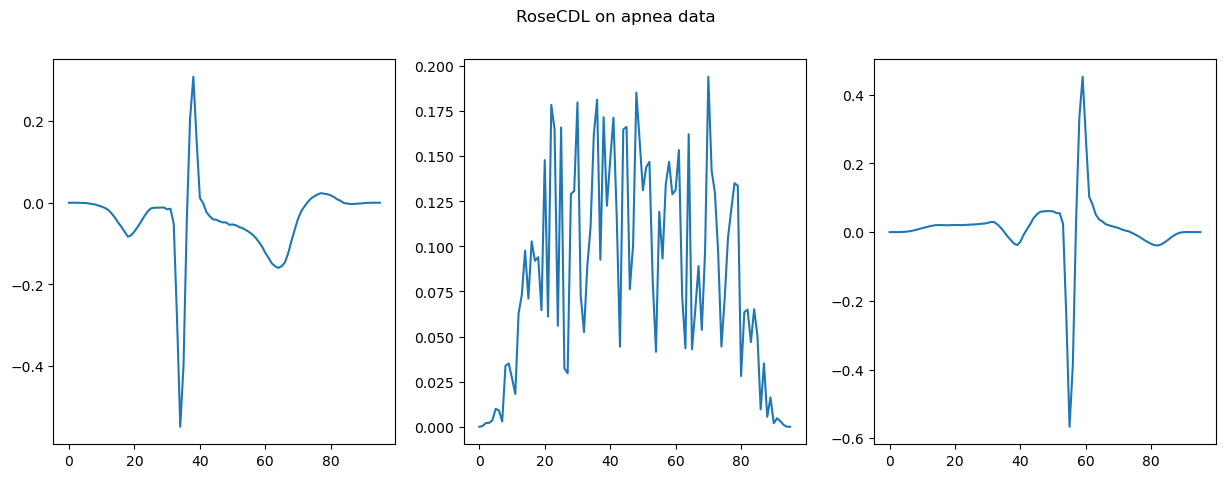

In [11]:
fig, axes = plt.subplots(1, rose.D_hat_.shape[0], figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.plot(rose.D_hat_[i].squeeze())

plt.suptitle("RoseCDL on apnea data")

Text(0.5, 0.98, 'RoseCDL on Normal ECG')

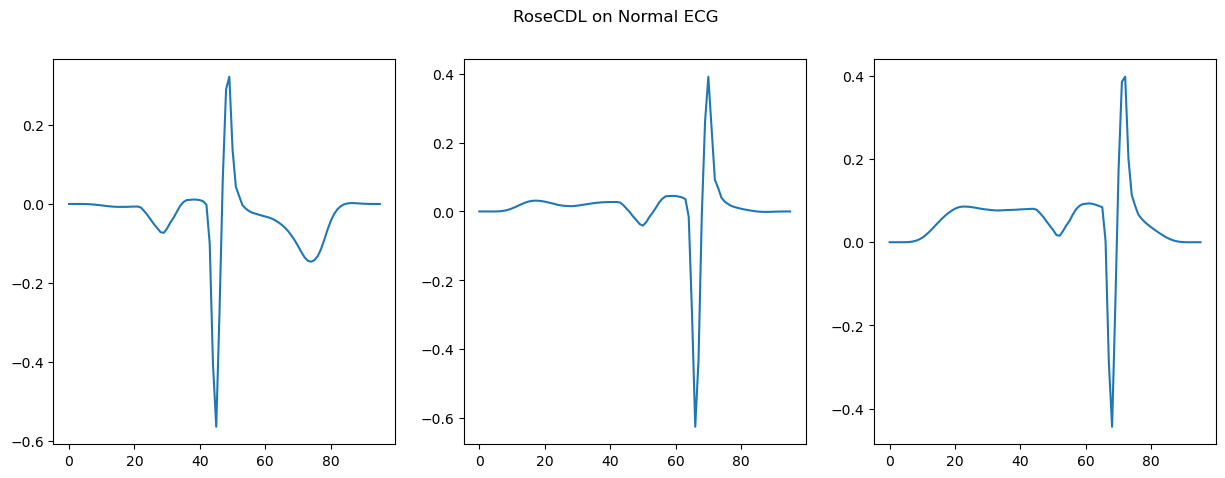

In [12]:
fig, axes = plt.subplots(1, rose_clean.D_hat_.shape[0], figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.plot(rose_clean.D_hat_[i].squeeze())

plt.suptitle("RoseCDL on Normal ECG")

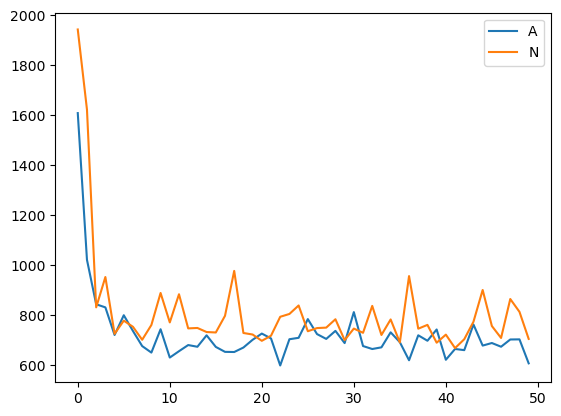

In [13]:
plt.plot(losses["A"], label="A")
plt.plot(losses["N"], label="N")
plt.legend()